In [18]:
import pandas as pd
import numpy as np
data = pd.read_csv("train_house.csv")
data["income_cat"] = pd.cut(data["median_income"],bins=[0,
1.5, 3.0, 4.5, 6.0, np.inf],labels=[1,2, 3, 4, 5])



In [19]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3


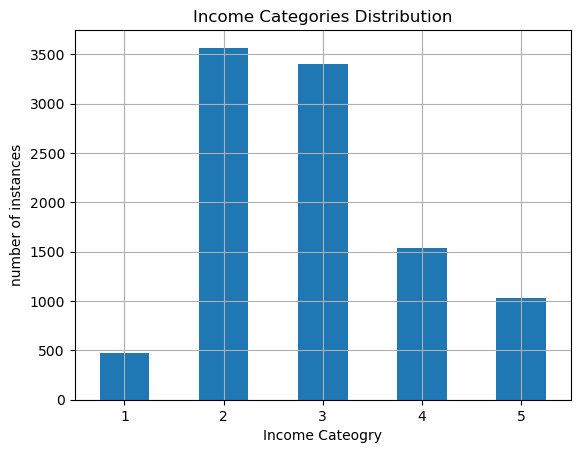

In [20]:
import matplotlib.pyplot as plt
data["income_cat"].value_counts().sort_index().plot.bar(rot =0,grid =True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Cateogry")
plt.ylabel("number of instances")
plt.show()
                                                       
                                                       

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit
split  = StratifiedShuffleSplit(n_splits= 1, test_size  =0.2, random_state =42)
for train_index , test_index in split.split(data,data["income_cat"]):
    strat_train_set =data.loc[train_index]
    strat_test_set =data.loc[test_index]
    

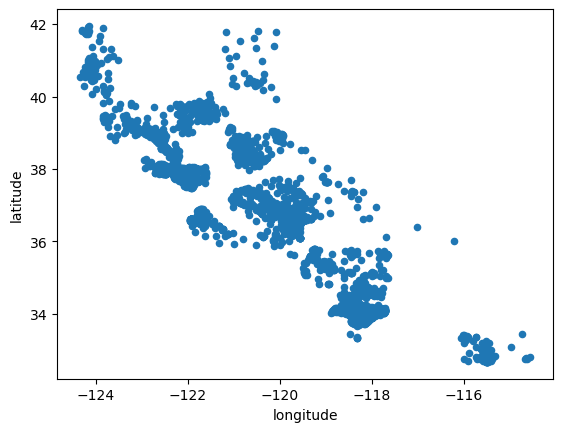

In [22]:
data.plot(kind  ="scatter" , x = "longitude" ,y  ="latitude" )
plt.show()

In [23]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3


In [24]:
df = data.drop("ocean_proximity", axis=1)

In [25]:
corr_matrix  = df.corr()
corr_matrix["median_house_value"].sort_values(ascending  =False)

median_house_value    1.000000
median_income         0.694939
income_cat            0.656894
total_rooms           0.213083
households            0.136412
total_bedrooms        0.125324
longitude             0.114511
housing_median_age    0.110208
population            0.011936
latitude             -0.259305
Name: median_house_value, dtype: float64

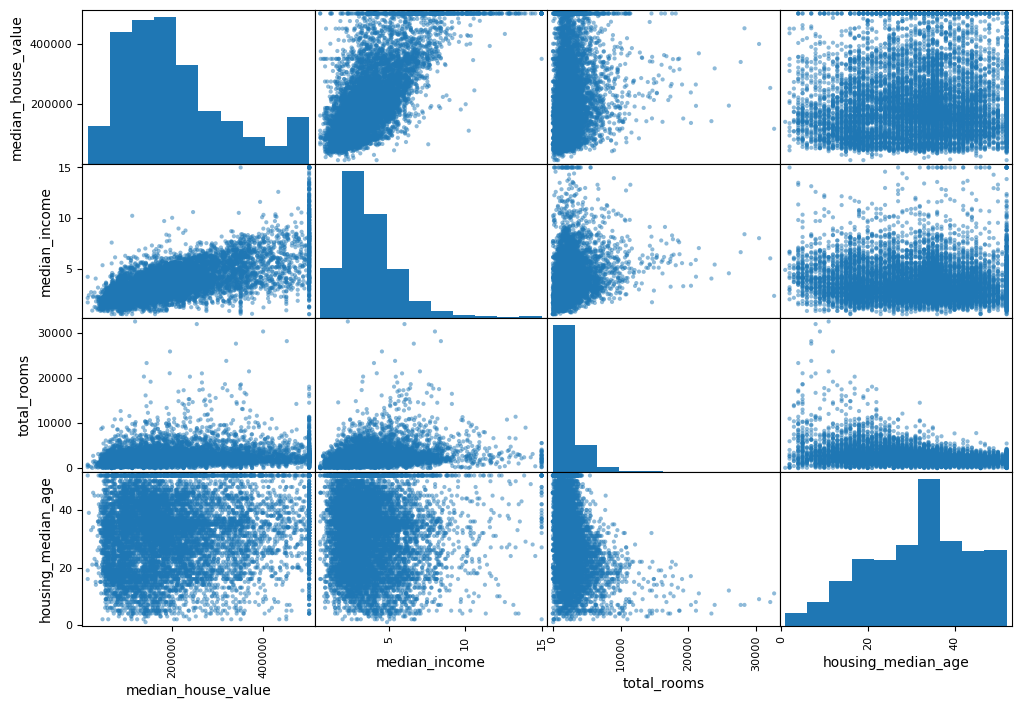

In [26]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income" ,"total_rooms","housing_median_age"]
scatter_matrix(df[attributes],figsize =(12,8))
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

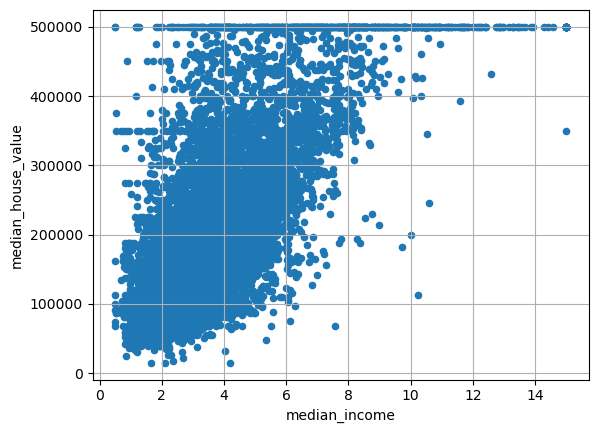

In [27]:
data.plot(kind ="scatter", x ="median_income" ,y  ="median_house_value" , grid =True)

In [28]:
housing  = strat_train_set.drop("median_house_value",axis =1)
housing_labels = strat_train_set["median_house_value"].copy()

In [29]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy ="median")
housing_num = housing.select_dtypes(include =[np.number])
imputer.fit(housing_num)


SimpleImputer(strategy='median')

In [30]:
X  =imputer.transform(housing_num)

In [31]:
X

array([[-1.18300e+02,  3.37300e+01,  4.70000e+01, ...,  1.13000e+03,
         5.60000e+02,  4.19400e+00],
       [-1.21840e+02,  3.97200e+01,  5.20000e+01, ...,  8.02000e+02,
         3.42000e+02,  9.56600e-01],
       [-1.21610e+02,  3.97700e+01,  2.50000e+01, ...,  8.37000e+02,
         3.03000e+02,  2.96300e+00],
       ...,
       [-1.18330e+02,  3.41700e+01,  4.40000e+01, ...,  7.50000e+02,
         3.65000e+02,  2.47300e+00],
       [-1.18420e+02,  3.40600e+01,  4.40000e+01, ...,  2.91000e+02,
         9.70000e+01,  1.08045e+01],
       [-1.15510e+02,  3.26800e+01,  1.10000e+01, ...,  2.64400e+03,
         5.81000e+02,  2.62500e+00]])

In [32]:
X_transformed = imputer.fit_transform(housing_num)

In [33]:
X_transformed

array([[-1.18300e+02,  3.37300e+01,  4.70000e+01, ...,  1.13000e+03,
         5.60000e+02,  4.19400e+00],
       [-1.21840e+02,  3.97200e+01,  5.20000e+01, ...,  8.02000e+02,
         3.42000e+02,  9.56600e-01],
       [-1.21610e+02,  3.97700e+01,  2.50000e+01, ...,  8.37000e+02,
         3.03000e+02,  2.96300e+00],
       ...,
       [-1.18330e+02,  3.41700e+01,  4.40000e+01, ...,  7.50000e+02,
         3.65000e+02,  2.47300e+00],
       [-1.18420e+02,  3.40600e+01,  4.40000e+01, ...,  2.91000e+02,
         9.70000e+01,  1.08045e+01],
       [-1.15510e+02,  3.26800e+01,  1.10000e+01, ...,  2.64400e+03,
         5.81000e+02,  2.62500e+00]])

In [38]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head()


,ocean_proximity
5659,NEAR OCEAN
1083,INLAND
1116,INLAND
6075,<1H OCEAN
6667,INLAND


In [39]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [40]:
housing_cat_encoded

array([[4.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]])

In [41]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [42]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder()
housing_cat1= one_hot.fit_transform(housing_num)

In [43]:
housing_cat1

<7999x16616 sparse matrix of type '<class 'numpy.float64'>'
	with 63992 stored elements in Compressed Sparse Row format>

In [44]:
housing_cat1.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [45]:
one_hot.categories_

[array([-124.35, -124.3 , -124.27, -124.23, -124.22, -124.21, -124.19,
        -124.18, -124.17, -124.16, -124.15, -124.14, -124.13, -124.11,
        -124.1 , -124.09, -124.08, -124.07, -124.06, -124.05, -124.03,
        -124.02, -124.01, -124.  , -123.98, -123.96, -123.92, -123.88,
        -123.85, -123.84, -123.83, -123.81, -123.8 , -123.79, -123.78,
        -123.75, -123.74, -123.73, -123.72, -123.71, -123.68, -123.66,
        -123.64, -123.59, -123.58, -123.54, -123.53, -123.52, -123.5 ,
        -123.47, -123.4 , -123.39, -123.38, -123.37, -123.36, -123.35,
        -123.34, -123.32, -123.23, -123.22, -123.21, -123.2 , -123.19,
        -123.17, -123.16, -123.15, -123.1 , -123.07, -122.99, -122.94,
        -122.93, -122.92, -122.91, -122.9 , -122.89, -122.88, -122.87,
        -122.86, -122.85, -122.84, -122.83, -122.81, -122.8 , -122.79,
        -122.78, -122.77, -122.75, -122.74, -122.73, -122.72, -122.71,
        -122.7 , -122.69, -122.68, -122.66, -122.65, -122.64, -122.63,
      

In [46]:
from sklearn.preprocessing import MinMaxScaler
min_max  = MinMaxScaler(feature_range=(-1,1))
housing_num_scaler =min_max.fit_transform(housing_num)

In [47]:
housing_num_scaler

array([[ 0.23469388, -0.77081081,  0.80392157, ..., -0.92108672,
        -0.81644737, -0.49047599],
       [-0.4877551 ,  0.52432432,  1.        , ..., -0.9440535 ,
        -0.88815789, -0.93700777],
       [-0.44081633,  0.53513514, -0.05882353, ..., -0.94160277,
        -0.90098684, -0.66026675],
       ...,
       [ 0.22857143, -0.67567568,  0.68627451, ..., -0.94769457,
        -0.88059211, -0.72785203],
       [ 0.21020408, -0.69945946,  0.68627451, ..., -0.97983405,
        -0.96875   ,  0.42130453],
       [ 0.80408163, -0.99783784, -0.60784314, ..., -0.81507545,
        -0.80953947, -0.7068868 ]])

In [48]:
from sklearn.preprocessing import StandardScaler
std =StandardScaler()
housing_std =  std.fit_transform(housing_num)

In [49]:
housing_std

array([[ 0.64839455, -0.900018  ,  1.28707085, ..., -0.24045813,
         0.20698206,  0.24973397],
       [-1.29745499,  2.14251345,  1.71076235, ..., -0.54356542,
        -0.37626442, -1.44647036],
       [-1.17102973,  2.1679102 , -0.57717174, ..., -0.51122166,
        -0.48060668, -0.39523654],
       ...,
       [ 0.6319043 , -0.67652655,  1.03285595, ..., -0.59161902,
        -0.31472924, -0.65196729],
       [ 0.58243355, -0.73239941,  1.03285595, ..., -1.0157844 ,
        -1.03174785,  3.71324133],
       [ 2.18198784, -1.4333499 , -1.76350794, ...,  1.15864076,
         0.26316635, -0.57232837]])

In [50]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline = make_pipeline(SimpleImputer(strategy ="median"),StandardScaler())
housing_num_prepared  = num_pipeline.fit_transform(housing_num)

In [51]:
print(housing_num_prepared[:2].round(2))

[[ 0.65 -0.9   1.29  0.21  0.22 -0.24  0.21  0.25]
 [-1.3   2.14  1.71 -0.48 -0.31 -0.54 -0.38 -1.45]]


In [52]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3


In [53]:
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5659,-118.30,33.73,47,2852,603.0,1130,560,4.1940
1083,-121.84,39.72,52,1457,389.0,802,342,0.9566
1116,-121.61,39.77,25,1612,313.0,837,303,2.9630
6075,-117.87,34.08,33,4518,716.0,2037,764,5.6015
6667,-118.10,34.17,44,4505,894.0,2296,899,3.4811


In [54]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared,
    columns = num_pipeline.get_feature_names_out(),
    index =housing_num.index
    )

In [55]:
df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5659,0.648395,-0.900018,1.287071,0.212603,0.221132,-0.240458,0.206982,0.249734
1083,-1.297455,2.142513,1.710762,-0.483195,-0.313462,-0.543565,-0.376264,-1.446470
1116,-1.171030,2.167910,-0.577172,-0.405884,-0.503318,-0.511222,-0.480607,-0.395237
6075,0.884755,-0.722241,0.100735,1.043569,0.503418,0.597707,0.752772,0.987180
6667,0.758330,-0.676527,1.032856,1.037085,0.948081,0.837051,1.113957,-0.123783
...,...,...,...,...,...,...,...,...
651,-1.456861,1.126643,1.117594,-0.055242,-0.158580,-0.355047,-0.103369,-0.101306
5556,0.587930,-0.783193,0.015996,-0.689191,-0.738140,-0.760731,-0.697318,0.225161
5880,0.631904,-0.676527,1.032856,-0.245277,-0.348436,-0.591619,-0.314729,-0.651967
5318,0.582434,-0.732399,1.032856,-0.944067,-1.060396,-1.015784,-1.031748,3.713241


In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
housing = pd.read_csv("housing.csv")
housing["income_cat"] = pd.cut(housing["median_income"], bins  =[0.,1.5,3.0,4.5,6.0 ,np.inf], labels =[1,2,3,4,5])
split =StratifiedShuffleSplit(n_splits =1,test_size  =0.2,random_state = 42)
for train_index,test_index in split.split(housing ,housing["income_cat"]):
    strat_train_set = housing.loc[train_index].drop("income_cat",axis =1)
    strat_test_set = housing.loc[test_index].drop("income_cat",axis =1)


housing = strat_train_set.copy()
housing_labels = housing["median_house_value"].copy()
housing =housing.drop("median_house_value",axis =1)
num_attribs = housing.drop("ocean_proximity" ,axis =1).columns.tolist()
cat_attribs  =["ocean_proximity"]
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

housing_prepared =full_pipeline.fit_transform(housing)
print(housing_prepared.shape)
                            

(16512, 13)


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)
tree_reg = DecisionTreeRegressor(random_state =42)
tree_reg.fit(housing_prepared,housing_labels)
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, housing_labels)
lin_preds = lin_reg.predict(housing_prepared)
tree_preds = tree_reg.predict(housing_prepared)
forest_preds = forest_reg.predict(housing_prepared)
lin_rmse = mean_squared_error(housing_labels,lin_preds,squared  =False)
tree_rmse = mean_squared_error(housing_labels,tree_preds,squared  =False)
forest_rmse = mean_squared_error(housing_labels,forest_preds,squared  =False)





C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [58]:
print("Linear Regression RMSE:", lin_rmse)
print("Decision Tree RMSE:", tree_rmse)
print("Random Forest RMSE:", forest_rmse)

Linear Regression RMSE: 69050.56219504567
Decision Tree RMSE: 0.0
Random Forest RMSE: 18342.366362322846


In [59]:
from sklearn.model_selection import cross_val_score
import pandas as pd
tree_rmse =-cross_val_score(
    tree_reg,
    housing_prepared,
    housing_labels,
    scoring ="neg_root_mean_squared_error",
    cv=10
)
print("Decison Tree CV rmse:",tree_rmse)
print("\nCross-Validation Performance (Decision Tree):")
print(pd.Series(tree_rmse).describe())

Decison Tree CV rmse: [71177.6601991  69770.07865373 64770.5639395  68536.60203993
 67057.08155801 68847.12456973 70977.38255647 69208.86346929
 67187.87131535 73280.38732407]

Cross-Validation Performance (Decision Tree):
count       10.000000
mean     69081.361563
std       2420.500173
min      64770.563939
25%      67525.053996
50%      69027.994020
75%      70675.556581
max      73280.387324
dtype: float64


In [60]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

Model_File ="model.pkl"
Pipeline_File = "pipeline.pkl"


def build_pipeline(num_attribs,cat_attribs):
    num_pipeline = Pipeline([("imputer",SimpleImputer(strategy ="median")),("scaler",StandardScaler())])
    cat_pipeline =Pipeline([("onehot" , OneHotEncoder(handle_unknown ="ignore"))])
    full_pipeline =ColumnTransformer([("num",num_pipeline,num_attribs),("cat",cat_pipeline,cat_attribs)])
    return full_pipeline

if not os.path.exists(Model_File):
    housing = pd.read_csv("housing.csv")
    housing["income_cat"] =pd.cut(housing['median_house_value'] , bins = [0.,1.5,3.0,4.5,6.0,np.inf],labels =[1,2,3,4,5])
    split  = StratifiedShuffleSplit(n_splits=1, test_size =0.2 , random_state =42)
    for train_index,  _ in  split.split(housing ,housing["income_cat"]):
        housing  =housing.loc[train_index].drop("income_cat",axis  =1)
    housing_labels = housing["median_house_value"].copy()
    housing_features = housing.drop('median_house_value',axis =1)
    num_attribs = housing_features.drop('ocean_proximity',axis =1).columns.tolist()
    cat_attribs =['ocean_proximity']
    pipeline =build_pipeline(num_attribs,cat_attribs)
    housing_prepared =pipeline.fit_transform(housing_features)
    model = RandomForestRegressor(random_state = 42)
    model.fit(housing_prepared,housing_labels)
    joblib.dump(model,Model_File)
    joblib.dump(pipeline,Pipeline_File)
    print("model trained and saved")

else:
    model =joblib.load(Model_File)
    pipeline  =joblib.load(Pipeline_File)
    input_data  =pd.read_csv("test_house.csv")
    transformed_input = pipeline.transform(input_data)
    predicitons  =model.predict(transformed_input)
    input_data["median_house_value"] = predicitons
    input_data.to_csv(r"C:\Users\Kapil\Desktop\machine_learning\output.csv", index=False)

    
    print("Inference complete. Results saved to output.csv")
    


    
         
   
                          
        
    



Inference complete. Results saved to output.csv
